<a href="https://colab.research.google.com/github/JosegregTovar/GOOGLE-COLLAB/blob/main/A01840476_MNA_IAyAA_Actividad_oil_spill_datos_desbalanceados_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Maestría en Inteligencia Artificial Aplicada**

###**Curso: Inteligencia Artificial y Aprendizaje Automático**

**Tecnológico de Monterrey**

Prof Luis Eduardo Falcón Morales

Alumno:

JOSEGREG DE JESUS TOVAR BLANCO A01840476

### **Actividad de la Semana: Problema de Clasificación con Datos Desbalanceados : Oil-Spill**

# **Introducción**

* La actividad se basa en los datos conocidos como "oil-spill" (derrame de petróleo).

* En la web puedes encontrar varias referencias a este mismo problema, pero en donde el archivo de datos no es exactamente igual. Por ello y para asegurar que el conjunto de datos con el que estaremos trabajando es el mismo para todos, dicho archivo lo encontrarás en Canvas.

* El archivo con los datos de esta actividad lo encuentras en Canvas con el nombre "oil-spill.csv".

En la siguiente liga se encuentra el artículo original relacionado a dicha base de datos. Los datos incluyen 50 columnas y 937 registros. Las primeras 49 columnas son métricas obtenidas de imágenes satelitales del océano, en algunas de las cuales se tiene petróleo que fue derramado por alguna fuente desconocida. En el artículo se describe a detalle la manera en que se obtuvieron dichas columnas. Para la actividad es suficiente considerarlas como de valor numérico, donde cada valor es una medida de información en la imagen. La última columna llamada "target" es de valor 1 (hay derrame en ese pedazo de la imagen) o 0 (no hay derrame en ese pedazo de la imagen).

https://webdocs.cs.ualberta.ca/~holte/Publications/oilspill.pdf

Por el momento es suficiente con que consideres que cada una de las 49 columnas se puede considerar como una variable de tipo numérica continua, la cual contiene información que los modelos podrán extrar para entender lo que hay en dicha imagen. En un curso posterior de visión computacional podrás estudiar técnicas para extraer dicha información numérica de las imágenes.

En la siguiente liga puedes encontrar información de varias de las métricas de scikit-learn que estaremos utilizando:

https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter

La librería de scikit-learn no incluye la media geométrica **G_mean**, pero sabemos que se puede obtener con la fórmula $G_{mean}=\sqrt{\frac{VP*VN}{(VP+FN) * (VN+FP)}}$, usando los verdaderos y falsos, positivos y negativos.

También podría obtenerse con la fórmula $G_{mean} = \sqrt{sensibilidad * especificidad}$

Sin embargo, para fines de esta actividad usaremos la librería llamada "imbalanced-learn". Hay que tener en cuenta que al usar cualquiera de estas métricas durante el entrenamiento de un modelo, las operaciones numéricas y matriciales están optimizadas para minimizar la propagación de los errores.

Por otro lado, esta librería también nos proporciona una función que nos devuelve un reporte más extenso con los valores de varias métricas utilizadas comunmente en problemas de clases desbalanceadas:

https://glemaitre.github.io/imbalanced-learn/generated/imblearn.metrics.geometric_mean_score.html

# **Ejercicio-1**

### **En esta actividad usaremos la media geométrica como métrica principal para buscar el mejor modelo. Responde a los siguientes incisos:**

* ### **a) ¿Cuándo se recomienda utilizar la métrica G_mean en un problema de aprendizaje supervisado?**

* ### **b) ¿Cuál es la diferencia, pros y contras, de la G_mean con la f1_score?**

* ### **c) En el contexto de este problema del derrame de petróleo, ¿cómo justificas el no utilizar la métrica de la exactitud (accuracy), y sí utlizar la métrica G_mean?**

* ### **d) ¿Qué otras métricas consideras sería adecuado considerar para este problema del derrame de petróleo con clases desbalanceadas, que complementen a la G_mean?**





### +++++++++++ Inicia sección para agregar texto ++++++++++++++++

* 1a) La métrica G_mean se recomienda en problemas de clasificación con clases desbalanceadas, donde se requiere evaluar el desempeño equilibrado del modelo sobre ambas clases. Es sobretodo bien útil cuando no basta con obtener una alta exactitud global, asi como en los casos de fraudes donde un modelo da por ejemplo el 99% que no son fraudes, y da un accuracy muy bueno, sino busca mantener simultáneamente una buena sensibilidad (proporcio de los recall de positivos) y especificidad (el recall negativo)

* 1b) La principal diferencia es que la F1-score combina precision y recall enfocándose mayormente en la clase positiva (util para utilizar en esos casos), mientras que la G_mean evalúa el balance entre sensibilidad y especificidad considerando ambas clases, penalizando modelos altamente sesgados. La G_mean es útil cuando se desea evitar sesgos hacia la clase mayoritaria mientras que la F1-score resulta buena cuando la prioridad es el desempeño sobre la clase positiva.

* 1c) En el problema del derrame de petróleo existe un fuerte desbalance de clases, ya que la mayoría de las observaciones corresponden a zonas sin derrame. En este contexto la accuracy puede resultar engañosa, haciendo al modelo inutil, porque un modelo podría obtener valores altos simplemente clasificando todos los casos como negativos, pero eso no hace que enefecto se detecte el derrame en tiempo. La métrica G_mean es más adecuada porque evalúa el desempeño equilibrado entre sensibilidad y especificidad, asegurando que el modelo detecte correctamente tanto los derrames como las zonas sin contaminación.

* 1d) Además de la G_mean, sería recomendable utilizar métricas como recall, precision y F1-score. El recall es especialmente importante porque permite evaluar qué proporción de derrames reales son detectados minimizando falsos negativos. La precision ayuda a controlar las falsas alarmas, mientras que la F1-score balancea ambas métricas. También se podrían considerar ROC-AUC y PR-AUC para evaluar la capacidad discriminativa del modelo en este contexto donde se ve que es de clases desbalanceadas.



### +++++++++++ Termina sección para agregar texto ++++++++++++++

In [18]:
# Incluye todas librerías que consideres necesarias:

import pandas as pd
import numpy as np
from numpy import mean, std

# Visualización

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


# Preprocesamiento de datos

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Particionado y validación cruzada

from sklearn.model_selection import (
    train_test_split,
    RepeatedStratifiedKFold,
    cross_val_score,
    cross_validate,
    GridSearchCV,
)

# Para modelos

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


# Métricas (sklearn)

from sklearn.metrics import (
    make_scorer,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    RocCurveDisplay,
    precision_recall_curve,
    PrecisionRecallDisplay,
    average_precision_score,
)

# Métricas específicas para clases desbalanceadas (imblearn)

from imblearn.metrics import geometric_mean_score, classification_report_imbalanced

# Silenciar warnings ruidosos para una salida limpia

import warnings
warnings.filterwarnings("ignore")





In [3]:
# Paleta personalizada

paleta_azules = {
    "petroleo_profundo": "#0B3D5C",
    "marino_nocturno":   "#1B4F72",
    "cobalto_intenso":   "#1A5490",
    "acero_metalico":    "#3B7EA1",
    "cerulean_vivo":     "#2E86AB",
    "electrico_neon":    "#00B4D8",
    "hielo_artico":      "#90E0EF",
    "polvo_estelar":     "#A9D6E5",
}

# Lista ordenada para usar como secuencia en gráficos
lista_azules = list(paleta_azules.values())



* **Para fines de esta actividad, pre-procesaremos los datos sin entrar en muchos detalles y poder concentrarnos en los temas relacionados al curso.**

* **Siempre podrás regresar en el futuro y trabajar de mejor manera el pre-procesamiento de los datos.**

In [4]:
#trabjando el archivo en mi drive

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
# Cargamos los datos del archivo:
path ="/content/drive/MyDrive/01 Maestría/03 Inteligencia Artifical Aplicada/Actividad 3/oil_spill (1).csv"
df = pd.read_csv(path)

# Eliminamos las siguientes columnas:
df.drop("f_1", axis=1, inplace=True)    # Esta columna contiene información de secciones (batches) de las imágenes que no requerimos para esta actividad.
df.drop("f_23", axis=1, inplace=True)   # Esta columna tiene un solo valor constante.


print('Dimensión del DataFrame',df.shape)
df.head(4).T


Dimensión del DataFrame (937, 48)


,0,1,2,3
f_2,2558.00,22325.00,115.00,1201.00
f_3,1506.09,79.11,1449.85,1562.53
f_4,456.63,841.03,608.43,295.65
f_5,90.00,180.00,88.00,66.00
f_6,6395000.00,55812500.00,287500.00,3002500.00
f_7,40.88,51.11,40.42,42.40
f_8,7.89,1.21,7.34,7.97
f_9,29780.00,61900.00,3340.00,18030.00
f_10,0.19,0.02,0.18,0.19
f_11,214.70,901.70,86.10,166.50


In [6]:
# Particionamos los datos de entrada (X) y de salida (y):
X,y = df.iloc[:,:-1], df.iloc[:,-1]

# Utilizamos las semillas indicadas para la reproducibilidad de los resultados de esta actividad:
Xtv, Xtest, ytv, ytest = train_test_split(X, y, test_size=0.12, stratify=y, shuffle=True, random_state=1)
Xtrain, Xval, ytrain, yval = train_test_split(Xtv, ytv, test_size=0.2, shuffle=True, random_state=7)


# Veamos la partición de los tres conjuntos.
# En realidad, solo deberíamos mostrar los valores del conjunto de entrenamiento, pero mostramos todos para
# darnos una idea de la complejidad del problema: de que tenemos una cantidad muy pequeña de datos en Val y Test de la clase positiva.

print('\nPartición:')
tmp = 100 * (ytrain.sum() / len(ytrain))
print('Train:')
print('Conteo_clase_positiva=%d, Porcentaje_clase_positiva=%.2f%%' % (ytrain.sum(), tmp))
print('Conteo_clase_negativa=%d, Porcentaje_clase_negativa=%.2f%%' % ((len(ytrain)-ytrain.sum()), 100-tmp))

print('\nValidation:')
tmp = 100 * (yval.sum() / len(yval))
print('Conteo_clase_positiva=%d, Porcentaje_clase_positiva=%.2f%%' % (yval.sum(), tmp))
print('Conteo_clase_negativa=%d, Porcentaje_clase_negativa=%.2f%%' % ((len(yval)-yval.sum()), 100-tmp))

print('\nTest:')
tmp = 100 * (ytest.sum() / len(ytest))
print('Conteo_clase_positiva=%d, Porcentaje_clase_positiva=%.2f%%' % (ytest.sum(), tmp))
print('Conteo_clase_negativa=%d, Porcentaje_clase_negativa=%.2f%%' % ((len(ytest)-ytest.sum()), 100-tmp))


Partición:
Train:
Conteo_clase_positiva=28, Porcentaje_clase_positiva=4.25%
Conteo_clase_negativa=631, Porcentaje_clase_negativa=95.75%

Validation:
Conteo_clase_positiva=8, Porcentaje_clase_positiva=4.85%
Conteo_clase_negativa=157, Porcentaje_clase_negativa=95.15%

Test:
Conteo_clase_positiva=5, Porcentaje_clase_positiva=4.42%
Conteo_clase_negativa=108, Porcentaje_clase_negativa=95.58%


**Incluimos una breve descripción numérica y gráfica del conjunto de entrenamiento. Es lo mínimo, para una primera aproximación. Más adelante puedes regresar a mejorar el pre-preocesamiento.**

**Puedes incluir más celdas con análisis adicionales, si así lo deseas.**

In [7]:
Xtrain.describe().T

,count,mean,std,min,25%,50%,75%,max
f_2,659.0,350.377845,1.911459e+03,10.00,19.000,63.00,134.000,28526.00
f_3,659.0,692.040516,6.013521e+02,1.92,83.905,646.26,1229.325,1789.13
f_4,659.0,853.822398,5.259526e+02,1.00,435.500,719.81,1238.040,2724.57
f_5,659.0,85.613050,4.564260e+01,0.00,54.000,74.00,120.500,180.00
f_6,659.0,831366.966616,4.158159e+06,71718.00,125000.000,185000.00,337500.000,71315000.00
f_7,659.0,43.517132,1.287405e+01,21.24,33.760,40.35,53.090,82.64
f_8,659.0,9.244294,3.590490e+00,1.21,6.935,8.33,11.045,23.47
f_9,659.0,4094.624431,8.960913e+03,704.00,1332.000,2100.00,3445.000,160740.00
f_10,659.0,0.221730,8.687786e-02,0.02,0.170,0.21,0.260,0.67
f_11,659.0,110.794537,6.187135e+01,41.00,84.400,100.10,116.300,901.70


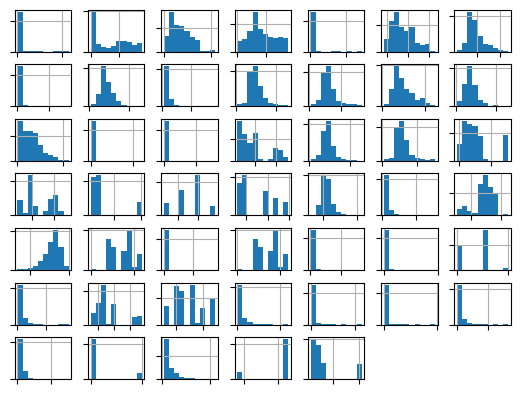

In [8]:
ax = Xtrain.hist()  # Histogramas:
# Quitemos toda la información del gráfico para visualizarlo de manera sencilla:
for axis in ax.flatten():
  axis.set_title('')
  axis.set_xticklabels([])
  axis.set_yticklabels([])
plt.show()



In [9]:
Xtrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 659 entries, 433 to 625
Data columns (total 47 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f_2     659 non-null    int64  
 1   f_3     659 non-null    float64
 2   f_4     659 non-null    float64
 3   f_5     659 non-null    int64  
 4   f_6     659 non-null    float64
 5   f_7     659 non-null    float64
 6   f_8     659 non-null    float64
 7   f_9     659 non-null    float64
 8   f_10    659 non-null    float64
 9   f_11    659 non-null    float64
 10  f_12    659 non-null    float64
 11  f_13    659 non-null    float64
 12  f_14    659 non-null    float64
 13  f_15    659 non-null    float64
 14  f_16    659 non-null    float64
 15  f_17    659 non-null    float64
 16  f_18    659 non-null    float64
 17  f_19    659 non-null    float64
 18  f_20    659 non-null    float64
 19  f_21    659 non-null    float64
 20  f_22    659 non-null    float64
 21  f_24    659 non-null    float64
 22  f_25 

**En resumen:**

* De lo anterior observamos que:
  * Todos los valores ya son numéricos, positivos, negativos o cero.
  * No hay datos perdidios.
  * La diferencia de escala entre todos los factores es muy diversa y la distribución de las variables también es muy variada.

* **Como una primera aproximación transformaremos todos los factores con la Yeo-Johnson para corregir un poco el sesgo de las distribuciones que suele afectar en general a los modelos como la regresión logística y luego los escalaremos para ayudar a que todos los factores estén en iguales condiciones de mostrar su importancia.**

# **Ejercicio-2**

### **En relación a la transformación Yeo-Johnson, investiga:**

* ### **a) ¿En qué consiste dicha transformación?**

* ### **b) ¿Cuál es su diferencia con la transformación Box-Cox?**


### +++++++++++ Inicia sección para agregar texto ++++++++++++++++

* 2a) La transformación Yeo-Johnson es una técnica de transformación de variables numéricas cuyo objetivo es reducir la asimetría o sesgo de una distribución. basicamente busca modificar la forma de los datos para que las variables tengan una distribución más simetrica y, en algunos casos, mas parecida a una distribución normal. Esta pertenece a la familia de transformaciones de potencia. Utiliza un parámetro llamado lambda, que determina qué tan fuerte será la transformación aplicada a cada variable. Dependiendo del valor de lambda, la variable puede transformarse de manera similar a una transformación logarítmica, lineal o de otro tipo.


* 2b) La principal diferencia entre Yeo-Johnson y Box-Cox es el tipo de valores que pueden manejar. La transformación Box-Cox solo puede aplicarse a variables con valores estrictamente positivos. Es decir, no acepta ceros ni valores negativos. Esto limita su uso cuando el conjunto de datos contiene variables con valores negativos o iguales a cero.


### +++++++++++ Termina sección para agregar texto ++++++++++++++

In [10]:
# Transformaciones numéricas evitando el filtrado de información:

from sklearn.preprocessing import MinMaxScaler

numericas_pipeline = Pipeline(steps = [('impMediana', SimpleImputer(strategy='mean')),
                                       ('yeo-johnson', PowerTransformer(method='yeo-johnson')),
                                       ('std_transformer', StandardScaler()),
                                       ])

numericas_pipeline_nombres = Xtrain.columns

columnasTransformer = ColumnTransformer(transformers = [('num', numericas_pipeline, numericas_pipeline_nombres)],
                                        remainder='passthrough')

In [11]:
# Definamos la siguiente variable con la métrica G-mean a utilizar en los modelos:

mi_metrica = make_scorer(geometric_mean_score)

# **Ejercicio-3**

* ### **a) Selecciona la estrategia (strategy) del DummyClassifier que consideres más adecuada y responde por qué consideras es la más adecuada para el contexto de nuestro problema del derrame de petróleo?**

* ### **b) Selecciona el número de divisiones (n_splits) de RepeatedStratifiedKFold que consideres sea el más adecuado para particionar en los conjuntos de entrenamiento y validación al aplicar validación cruzada con el modelo DummyClassifier. Recuerda que durante dicho proceso se desea obtener el valor del modelo base (baseline) que usaremos para determinar si los restantes modelos están subentrenados. Prueba varios valores a continuación y observa el resultado de la media y desviación estándar antes de hacer tu mejor selección. Responde a continuación cómo llegaste a decidirte por valor que seleccionaste.**

* ### **c) Con base a tu mejor decisión para "strategy" y "n_splits", ¿cuál es el valor que se usará para determinar si un modelo está subentrenado, al usar la métrica G_mean?**

* ### **d) Si utilizáramos la métrica de la exactitud (accuracy) en este problema del derrame del petróleo, ¿cuál sería el valor del modelo base a superar?** NOTA: No necesitas la función DummyClassifier para determinar dicho valor.

### +++++++++++ Inicia sección para agregar texto ++++++++++++++++


* 3a) Respuesta:

La estrategia seleccionada para el DummyClassifier es stratified. Hice ver varias estrategias (dejé el código) Y de ese analisis aunque la estrategia uniform obtuvo una G_mean promedio mayor, no se considera la más adecuada para este problema porque predice las clases con probabilidades similares, como si los derrames y no derrames fueran igualmente frecuentes. Esto no representa el contexto real del conjunto de datos, donde la clase positiva correspondiente a derrames de petróleo es muy minoritaria. Las estrategias most_frequent y prior tampoco son adecuadas porque tienden a predecir siempre la clase mayoritaria, (Por eso obtienen una G_mean igual a 0)

* 3b) Respuesta:

Estuvo complicado, tras probar valores de n_splits entre 2 y 15 con el DummyClassifier(strategy="stratified") y n_repeats=3, observé tres comportamientos relevantes:

La G‑mean media del baseline es muy baja en todos los casos (entre 0.00 y 0.11), lo cual es el comportamiento esperado del Dummy estratificado sobre un dataset con 96% de desbalance: la probabilidad de que el Dummy acierte un positivo es aproximadamente la frecuencia de la clase positiva al cuadrado

Para valores altos de n_splits (≥ 7) aparecen folds donde el baseline obtiene G‑mean = 0 exacto en todas las repeticiones (n_splits = 7, 10, 14). Esto ocurre porque el conjunto de validación queda con tan pocos positivos (2‑3 derrames) que el Dummy estratificado nunca logra predecir uno correctamente, lo que indica que esos valores no son estadísticamente confiables para este dataset.
Para valores bajos de n_splits (2‑3), la media es ligeramente más alta y el coeficiente de variación es el menor del rango (144%‑187%), pero se entrena con muy pocos datos por iteración, lo que comprometería la calidad del baseline comparado con los modelos del Ejercicio 5.

**Elegí n_splits = 5 porque:**

Es el estándar metodológico en validación cruzada para problemas desbalanceados pequeños, lo que lei permite comparabilidad directa con la celda "Código‑1" del Ejercicio 4 que también usa n_splits = 5.
Cada fold conserva de 6 a 7 positivos en validación, suficiente para que la métrica no colapse a cero.
Aunque el coeficiente de variación es alto (255%), el valor absoluto importa menos que la separación que cualquier modelo inteligente logre sobre él. El propósito del Dummy NO es darme una métrica precisa. Es darte un piso "miserable" que cualquier modelo decente debería pulverizar de aqui en adelante.

* 3c) Respuesta:

El valor de G‑mean a superar para que un modelo no se considere subentrenado es aproximadamente 0.054 (con n_splits=5, n_repeats=3, random_state=7). Cualquier modelo "inteligente" debe obtener una G‑mean claramente superior a este piso.

* 3d) respuesta:

Si se utilizara accuracy, el modelo base a superar sería el porcentaje de la clase mayoritaria. En el conjunto de entrenamiento, la clase negativa tiene 631 registros de un total de 659, por lo que el accuracy base sería: (631 / 659 = 0.9575) es decir aproximadamente 95.75%. pero este valor es engañoso ya que un modelo que siempre predijera “no derrame” tendría una exactitud muy alta, pero no detectaría ningún derrame real. Por esta razón, accuracy no es una métrica adecuada como criterio principal en este problema desbalanceado.


### +++++++++++ Termina sección para agregar texto ++++++++++++++

NOTA: Recuerda revisar la documentación correspondiente de sklearn para la selección adecuada de los argumentos:

* DummyClassifier:

https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html

* RepeatedStratifiedKFold:

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedStratifiedKFold.html

In [14]:
# Comparación de estrategias del DummyClassifier


estrategias_dummy = [
    "most_frequent",
    "prior",
    "stratified",
    "uniform"
]

resultados_estrategias = []

for estrategia in estrategias_dummy:

    modelo_dummy = Pipeline(steps=[
        ("preprocesamiento", columnasTransformer),
        ("modelo", DummyClassifier(
            strategy=estrategia,
            random_state=17
        ))
    ])

    validacion_cruzada = RepeatedStratifiedKFold(
        n_splits=5,
        n_repeats=3,
        random_state=7
    )

    puntajes = cross_val_score(
        modelo_dummy,
        Xtrain,
        ytrain,
        scoring=mi_metrica,
        cv=validacion_cruzada,
        n_jobs=-1
    )

    resultados_estrategias.append({
        "strategy": estrategia,
        "G_mean_promedio": puntajes.mean(),
        "G_mean_desviacion": puntajes.std()
    })

resultados_estrategias = pd.DataFrame(resultados_estrategias).round(4)

display(resultados_estrategias)


,strategy,G_mean_promedio,G_mean_desviacion
0,most_frequent,0.0000,0.0000
1,prior,0.0000,0.0000
2,stratified,0.0561,0.1432
3,uniform,0.5732,0.0801


In [13]:
# Búsqueda empírica del mejor n_splits para RepeatedStratifiedKFold
# Estrategia del Dummy fijada en "stratified" (decisión del inciso 3a)


from matplotlib.colors import LinearSegmentedColormap

# --- Rango de n_splits a evaluar ---
# Empezamos en 2 porque K-Fold requiere al menos 2 folds.
rango_nsplits = range(2, 16)

# --- Almacén de resultados ---
resultados_busqueda = []

for n in rango_nsplits:
    cv_temp = RepeatedStratifiedKFold(n_splits=n, n_repeats=3, random_state=7)
    modelo_dummy_temp = DummyClassifier(strategy="stratified", random_state=7)
    pipeline_temp = Pipeline(steps=[("ct", columnasTransformer),
                                    ("Dummy", modelo_dummy_temp)])

    scores_temp = cross_val_score(pipeline_temp, Xtrain, ytrain,
                                  scoring=mi_metrica, cv=cv_temp, n_jobs=-1)

    media_temp = mean(scores_temp)
    std_temp = std(scores_temp)
    cv_pct = (std_temp / media_temp * 100) if media_temp > 0 else np.nan

    resultados_busqueda.append({
        "n_splits": n,
        "G-mean (media)": round(media_temp, 4),
        "G-mean (std)": round(std_temp, 4),
        "Coef. variación (%)": round(cv_pct, 2),
    })

# --- Convertir a DataFrame ---
tabla_resultados = pd.DataFrame(resultados_busqueda).set_index("n_splits")

# --- Paleta personalizada para el styling ---
cmap_azules = LinearSegmentedColormap.from_list(
    "azules_custom",
    [paleta_azules["polvo_estelar"],
     paleta_azules["cerulean_vivo"],
     paleta_azules["petroleo_profundo"]]
)
cmap_azules_inv = LinearSegmentedColormap.from_list(
    "azules_custom_inv",
    [paleta_azules["petroleo_profundo"],
     paleta_azules["cerulean_vivo"],
     paleta_azules["polvo_estelar"]]
)

# Mostrar tabla

print(" Resultados de la búsqueda (más oscuro = mejor en cada columna):\n")
display(
    tabla_resultados.style
    .background_gradient(subset=["G-mean (media)"], cmap=cmap_azules)
    .background_gradient(subset=["G-mean (std)"], cmap=cmap_azules_inv)
    .background_gradient(subset=["Coef. variación (%)"], cmap=cmap_azules_inv)
    .format(precision=4)
)

📊 Resultados de la búsqueda (más oscuro = mejor en cada columna):



,G-mean (media),G-mean (std),Coef. variación (%)
n_splits,,,
2,0.1061,0.1533,144.5400
3,0.0713,0.1335,187.1700
4,0.0624,0.1395,223.6100
5,0.0540,0.1377,254.9500
6,0.0495,0.1399,282.8400
7,0.0000,0.0000,nan
8,0.0414,0.1373,331.6600
9,0.0212,0.1083,509.9000
10,0.0000,0.0000,nan


In [15]:
# Utilicemos la función DummyClassifier de sklearn con la métrica G-mean para
# obtener el desempeño del modelo base (baseline).

# Usa esta celda para probar diferentes valores de "strategy" y "n_splits".
# Con base a los resultados observados selecciona tus mejores opciones y
# responde a las preguntas de los incisos anteriores del Ejercicio-3.


# ----------------- Incluye a continuación tus mejores opciones -----------

mi_estrategia = "stratified"

mi_nsplits = 5


# ----------------- Fin para realizar ajustes -----------------------------



# No modifiques las semillas.
cv = RepeatedStratifiedKFold(n_splits=mi_nsplits, n_repeats=3, random_state=7)  # Validación Cruzada Estratificada.
modeloD = DummyClassifier(strategy=mi_estrategia, random_state=7)
pipelineD = Pipeline(steps=[('ct',columnasTransformer),('Dummy',modeloD)])
scores = cross_val_score(pipelineD, Xtrain, ytrain, scoring=mi_metrica, cv=cv, n_jobs=-1)  # Cuidamos el filtrado de información.

print('Veamos los desempeños obtenidos con la DummyClassifier y la métrica G-mean.')
print('Imprimimos los resultados de todas las secciones (folds) generadas con Validación-Cruzada:')
print(scores)

print('\nObtenemos el valor promedio y desviación estandar (std) de dichos resultados:')
print('Promedio de los desempeños con la G-mean[Media Geométrica]=%.3f, std=(%.3f)' % (mean(scores), std(scores)))


Veamos los desempeños obtenidos con la DummyClassifier y la métrica G-mean.
Imprimimos los resultados de todas las secciones (folds) generadas con Validación-Cruzada:
[0.         0.         0.         0.         0.         0.
 0.         0.40499526 0.         0.         0.         0.
 0.         0.40499526 0.        ]

Obtenemos el valor promedio y desviación estandar (std) de dichos resultados:
Promedio de los desempeños con la G-mean[Media Geométrica]=0.054, std=(0.138)


* ### **Ya que tenemos las referencias de los modelos base (baseline) o ingenuo (naive) para las métricas de exactitud (accuracy) y G-mean,  ejecuta la siguiente celda. Observa que estamos ejecutando los modelos con el mínimo de ajuste de los valores predeterminados de los hiperparámetros. Esto con el objetivo de tener un punto de partida sobre qué tan alejados estamos de obtener buenos modelos. Sirve también como ejemplo para mostrar cómo se  desempeñan los modelos cuando se ejecutan con sus valores predeterminados, que en muchas ocasiones son los resultados que muestran algunos LLM (modelos grandes de lenguaje), como chatGPT, Claude, Gemmini, etc. Esto nos muestra que no porque no tengamos errores de ejecución o compilación, no significa que ya alcanzamos el objetivo buscado.**

* ### **Observa que estamos usando los conjuntos Xtv y ytv para entrenar los modelos ya que estamos utilizando validación cruzada y además, mostramos al inicio que tenemos muy pocos datos de la clase positiva minoritaria en el conjunto de validación.**

Resultados de Validación:
LR
Exactitud: >> 0.947 (0.015)
G-mean: >> 0.654 (0.119)

LASSO
Exactitud: >> 0.960 (0.009)
G-mean: >> 0.501 (0.158)

RIDGE
Exactitud: >> 0.959 (0.008)
G-mean: >> 0.541 (0.113)

EN
Exactitud: >> 0.960 (0.007)
G-mean: >> 0.540 (0.109)

kNN
Exactitud: >> 0.956 (0.006)
G-mean: >> 0.174 (0.187)



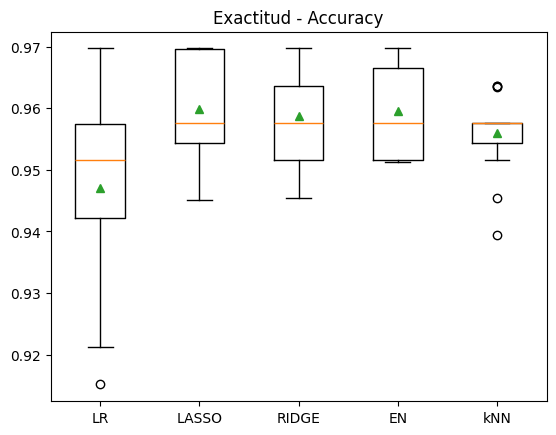

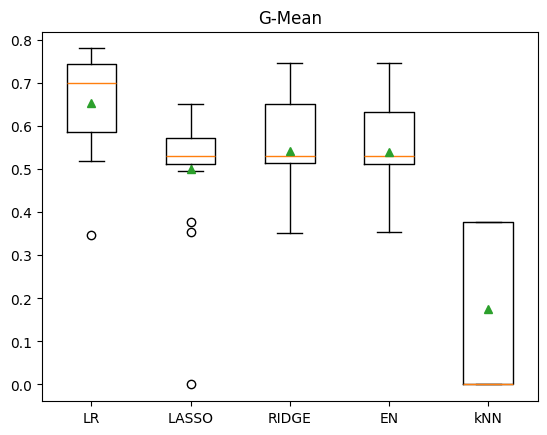

In [16]:
# Código-1:

# Ejecuta esta celda sin modificaciones.

# Estamos ejecutando los modelos con el mínimo de ajustes para usar sus valores predetermiandos
# y mostrando los desempeños con las métricas de exactitud (accuracy) y G-mean.                   # tarda unos 30 segs

# Definimos primeramente los modelos a entrenar y evaluar:

def mis_modelos1():
  modelos, nombres = list(), list()

  modelos.append(LogisticRegression(penalty=None, # Este valor del argumento define el modelo sin regularización.
                                    max_iter=2000,
                                    random_state=1))
  nombres.append('LR')


  modelos.append(LogisticRegression(penalty='l1',  # modelo Lasso o de métrica L1.
                                    solver='liblinear',
                                    max_iter=2000,
                                    random_state=1))
  nombres.append('LASSO')


  modelos.append(LogisticRegression(penalty='l2',   # modelo Ridge o de métrica L2.
                                    max_iter=2000,
                                    random_state=1))
  nombres.append('RIDGE')

  modelos.append(LogisticRegression(penalty='elasticnet',  # modelo Elastic-Net o de métrica L1-L2.
                                    l1_ratio=0.5,
                                    solver='saga',
                                    max_iter=5000,
                                    random_state=1))
  nombres.append('EN')

  modelos.append(KNeighborsClassifier(n_neighbors=5))
  nombres.append('kNN')

  return modelos, nombres

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++


modelos, nombres = mis_modelos1()
resultados1, resultados2 = list(), list()
print('Resultados de Validación:')

for i in range(len(modelos)):

  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])
  cv1 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)
  scores = cross_validate(pipeline,
                          Xtv,
                          np.ravel(ytv),
                          scoring={'exactitud':'accuracy', 'm_geo':mi_metrica},
                          cv=cv1)

  resultados1.append(scores['test_exactitud'])
  resultados2.append(scores['test_m_geo'])

  print(nombres[i])
  print('Exactitud: >> %.3f (%.3f)' % (np.nanmean(scores['test_exactitud']), np.nanstd(scores['test_exactitud'])))
  print('G-mean: >> %.3f (%.3f)' % (np.nanmean(scores['test_m_geo']), np.nanstd(scores['test_m_geo'])))
  print()

plt.boxplot(resultados1, tick_labels=nombres,  showmeans=True)
plt.title("Exactitud - Accuracy")
plt.show()

plt.boxplot(resultados2, tick_labels=nombres,  showmeans=True)
plt.title("G-Mean")
plt.show()




# **Ejercicio-4**

### **Habiendo ejecutado la celda anterior sin ajustar hiperparámetros, responde lo siguiente:**

### **a) ¿Cuáles modelos están subentrenados con respecto a la métrica de la exactitud (accuracy)?**

### **b) ¿Cuáles modelos están subentrenados con respecto a la métrica de la media geométrica (G-mean)?**


### +++++++++++ Inicia sección para agregar texto ++++++++++++++++


* 4a) Respuesta:

El baseline de accuracy en este problema es aproximadamente (96%), correspondiente al porcentaje de la clase mayoritaria — equivalente a un modelo trivial que siempre predice un "no hay ningun derrame"

LR (Logistic Regression sin regularización): accuracy = 0.947 ± 0.015. Queda por debajo del baseline por tanto, **subentrenado **respecto a accuracy.

kNN (k=5): accuracy = 0.956 ± 0.006. También queda por debajo del baseline , por tanto **subentrenado** respecto a accuracy.

LASSO (0.960), RIDGE (0.959), EN (0.960): empatan con el baseline o lo igualan prácticamente.

Técnicamente no están subentrenados según el criterio estricto, pero es sospechoso el hecho de que igualen al modelo trivial,  es sin duda una señal de alarma: indica que probablemente están "aprendiendo" a predecir casi siempre la clase mayoritaria, replicando el comportamiento del baseline. Esto evidencia precisamente por qué la accuracy es una métrica bien engañosa en este problema.


* 4b) Respuesta:

El baseline de G‑mean es aproximadamente 0.054, obtenido con el DummyClassifier(strategy="stratified") y RepeatedStratifiedKFold(n_splits=5, n_repeats=3).

LR: G‑mean = 0.654 ± 0.119. Supera ampliamente el baseline (≈ 12× superior). **No subentrenado.**

LASSO: G‑mean = 0.501 ± 0.158. Supera el baseline **No subentrenado.**
RIDGE: G‑mean = 0.541 ± 0.113. Supera el baseline **No subentrenado.**
EN: G‑mean = 0.540 ± 0.109. Supera el baseline.** No subentrenado.**
kNN: G‑mean = 0.174 ± 0.187. Aunque su media supera el baseline, la desviación estándar (0.187) es mayor que la media (0.174)  muy cerca de comportarse como un modelo subentrenado. **Se considera subentrenado **en términos prácticos por su gran variabilidad respecto al baseline.



### +++++++++++ Termina sección para agregar texto ++++++++++++++

# **Ejercicio-5**

* ### **Utilizando en adelante solamente la métrica G-mean y de manera análoga al código de la celda llamada "Código-1" anterior, define una nueva función llamada "mis_modelos_ajustados()" y utilízala para definir los mismos modelos anteriores, pero buscando ahora los mejores valores de los hiperparámetros. Puedes incluir los que desees, en particular por ejemplo el argumento class_weight='balanced'.**

* ### **La salida no deberá mostrar errores o advertencias (warnings).**

* ### **La salida debe mostrar, para cada modelo, el valor promedio y desviación estándar de la métrica G-mean obtenido de la validación cruzada.**

* ### **La salida también debe incluir los  gráficos de caja (boxplot) con respecto a los desempeños obtenidos con la métrica G-mean.**


* ### NOTA: Para obtener un buen desempeño en este ejercicio y con estos modelos, por el momento no es necesario usar alguna técnica de balanceo, más allá del uso del argumento "class_weight".

In [20]:
# 5)
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++
# NOTA: puedes agregar todas las celdas que consideres adecuado.

# Lo voy a dividir en varios codigos porque se pone pesado

#PARTE 1

# Modelos candidatos (mismos del Código-1) + grids de hiperparámetros


modelos_candidatos = [
    ("LR", LogisticRegression(
        penalty=None,
        max_iter=3000,
        random_state=1
    )),
    ("LASSO", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=3000,
        random_state=1
    )),
    ("RIDGE", LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=3000,
        random_state=1
    )),
    ("EN", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=5000,
        random_state=1
    )),
    ("kNN", KNeighborsClassifier())
]

parametros_modelos = {

    # LR sin regularización: solo se puede ajustar class_weight y el solver compatible
    "LR": {
        "modelo__class_weight": [None, "balanced"],
        "modelo__solver": ["lbfgs", "newton-cg"]
    },

    "LASSO": {
        "modelo__C": [0.01, 0.1, 1, 10],
        "modelo__class_weight": [None, "balanced"]
    },

    "RIDGE": {
        "modelo__C": [0.01, 0.1, 1, 10],
        "modelo__class_weight": [None, "balanced"]
    },

    "EN": {
        "modelo__C": [0.1, 1, 10],
        "modelo__l1_ratio": [0.3, 0.5, 0.7],
        "modelo__class_weight": [None, "balanced"]
    },

    "kNN": {
        "modelo__n_neighbors": [3, 5, 7, 9, 11],
        "modelo__weights": ["uniform", "distance"],
        "modelo__metric": ["euclidean", "manhattan"]
    }
}


# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++


In [21]:
# PARTE 2
# Función para ajustar modelos con búsqueda de hiperparámetros


def mis_modelos_ajustados(modelos, parametros, X, y, columnas_transformer, metrica, n_splits=5):

    nombres_modelos = []
    mejores_modelos = []
    mejores_parametros = []
    mejores_scores = []
    resultados_cv = []

    cv = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=3,
        random_state=7
    )

    for nombre_modelo, modelo in modelos:

        pipeline_modelo = Pipeline(steps=[
            ("ct", columnas_transformer),
            ("modelo", modelo)
        ])

        busqueda = GridSearchCV(
            estimator=pipeline_modelo,
            param_grid=parametros[nombre_modelo],
            scoring=metrica,
            cv=cv,
            n_jobs=-1,
            refit=True,
            error_score="raise"
        )

        busqueda.fit(X, y)

        nombres_modelos.append(nombre_modelo)
        mejores_modelos.append(busqueda.best_estimator_)
        mejores_parametros.append(busqueda.best_params_)
        mejores_scores.append(busqueda.best_score_)

        resultados_temporales = pd.DataFrame(busqueda.cv_results_)
        resultados_temporales["modelo"] = nombre_modelo
        resultados_cv.append(resultados_temporales)

    resumen_modelos = pd.DataFrame({
        "modelo": nombres_modelos,
        "mejor_G_mean": mejores_scores,
        "mejores_parametros": mejores_parametros,
        "mejor_estimador": mejores_modelos
    }).sort_values(by="mejor_G_mean", ascending=False).reset_index(drop=True)

    resultados_cv = pd.concat(resultados_cv, ignore_index=True)

    return resumen_modelos, resultados_cv

In [22]:
# PARTE 3

# Ejecutar búsqueda de mejores modelos con G-mean

resumen_modelos_ajustados, resultados_cv_ajustados = mis_modelos_ajustados(
    modelos=modelos_candidatos,
    parametros=parametros_modelos,
    X=Xtrain,
    y=ytrain,
    columnas_transformer=columnasTransformer,
    metrica=mi_metrica,
    n_splits=mi_nsplits
)

display(resumen_modelos_ajustados[[
    "modelo",
    "mejor_G_mean",
    "mejores_parametros"
]])

,modelo,mejor_G_mean,mejores_parametros
0,LASSO,0.801665,"{'modelo__C': 0.1, 'modelo__class_weight': 'ba..."
1,EN,0.764709,"{'modelo__C': 0.1, 'modelo__class_weight': 'ba..."
2,RIDGE,0.753865,"{'modelo__C': 0.01, 'modelo__class_weight': 'b..."
3,LR,0.638007,"{'modelo__class_weight': 'balanced', 'modelo__..."
4,kNN,0.295811,"{'modelo__metric': 'euclidean', 'modelo__n_nei..."


📊 Resultados de validación cruzada con G-mean (modelos ajustados):

LR     → G-mean: 0.6380 (0.1081)
LASSO  → G-mean: 0.8017 (0.0738)
RIDGE  → G-mean: 0.7539 (0.1011)
EN     → G-mean: 0.7647 (0.1184)
kNN    → G-mean: 0.2958 (0.2127)


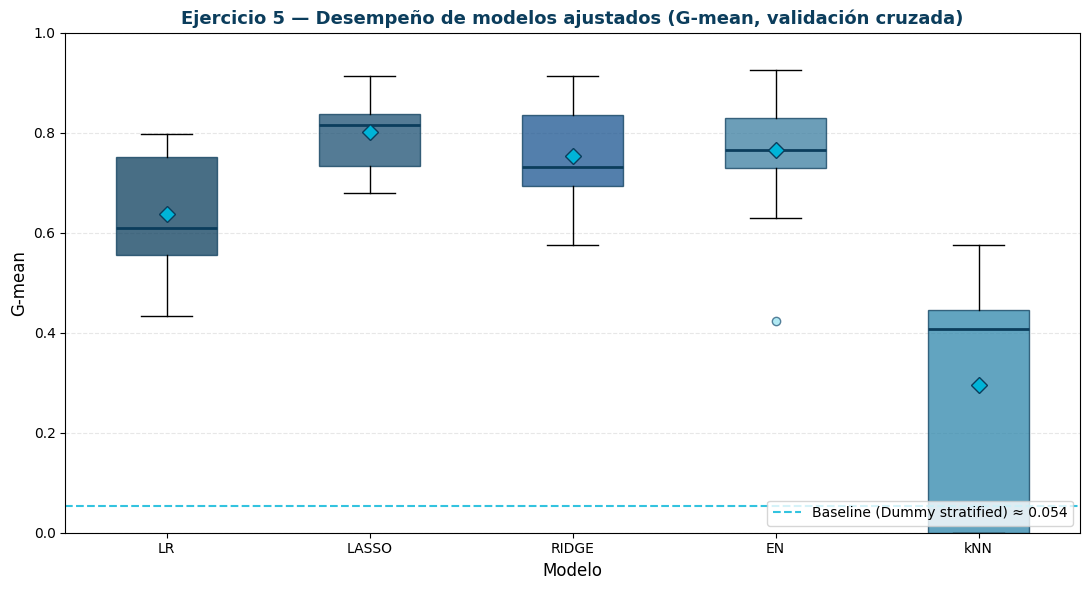

In [23]:
#PARTE 4
# Evaluación final: media, std y boxplot por modelo


scores_por_modelo = []
nombres_por_modelo = []

print("📊 Resultados de validación cruzada con G-mean (modelos ajustados):\n")

# Recorremos los mejores estimadores en el ORDEN ORIGINAL (no el ordenado por score)
# para mantener consistencia con el Código-1 del Ejercicio 4
orden_original = ["LR", "LASSO", "RIDGE", "EN", "kNN"]

cv_final = RepeatedStratifiedKFold(n_splits=mi_nsplits, n_repeats=3, random_state=7)

for nombre in orden_original:
    fila = resumen_modelos_ajustados[resumen_modelos_ajustados["modelo"] == nombre].iloc[0]
    mejor_pipeline = fila["mejor_estimador"]

    scores_modelo = cross_val_score(
        mejor_pipeline,
        Xtrain, ytrain,
        scoring=mi_metrica,
        cv=cv_final,
        n_jobs=-1
    )

    scores_por_modelo.append(scores_modelo)
    nombres_por_modelo.append(nombre)

    print(f"{nombre:6s} → G-mean: {mean(scores_modelo):.4f} ({std(scores_modelo):.4f})")

# Boxplots

fig, ax = plt.subplots(figsize=(11, 6))

bp = ax.boxplot(
    scores_por_modelo,
    labels=nombres_por_modelo,
    patch_artist=True,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": paleta_azules["electrico_neon"],
        "markeredgecolor": paleta_azules["petroleo_profundo"],
        "markersize": 8
    },
    medianprops={"color": paleta_azules["petroleo_profundo"], "linewidth": 2},
    flierprops={
        "marker": "o",
        "markerfacecolor": paleta_azules["hielo_artico"],
        "markeredgecolor": paleta_azules["marino_nocturno"],
        "markersize": 6,
        "alpha": 0.7
    }
)

colores_cajas = [
    paleta_azules["petroleo_profundo"],
    paleta_azules["marino_nocturno"],
    paleta_azules["cobalto_intenso"],
    paleta_azules["acero_metalico"],
    paleta_azules["cerulean_vivo"]
]

for parche, color in zip(bp["boxes"], colores_cajas):
    parche.set_facecolor(color)
    parche.set_alpha(0.75)
    parche.set_edgecolor(paleta_azules["petroleo_profundo"])

# Línea de baseline del DummyClassifier
ax.axhline(
    y=0.054,
    color=paleta_azules["electrico_neon"],
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
    label="Baseline (Dummy stratified) ≈ 0.054"
)

ax.set_ylabel("G-mean", fontsize=12)
ax.set_xlabel("Modelo", fontsize=12)
ax.set_title(
    "Ejercicio 5 — Desempeño de modelos ajustados (G-mean, validación cruzada)",
    fontsize=13,
    fontweight="bold",
    color=paleta_azules["petroleo_profundo"]
)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)
ax.legend(loc="lower right", fontsize=10)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

En base en los resultados de validación cruzada usando una G-mean, el modelo con mejor desempeño fue LASSO, con una G-mean promedio de 0.8017 y una desviación estándar de 0.0738. Este resultado supera ampliamente el baseline obtenido con DummyClassifier, cuyo valor fue aproximadamente 0.1061.

Esto indica que LASSO si está aprendiendo patrones útiles en los datos y logra un mejor equilibrio entre la detección de derrames y la correcta clasificación de casos sin derrame. Además, su desviación estándar relativamente baja sugiere que su desempeño es más estable entre las particiones de validación cruzada.

Los modelos RIDGE y Elastic Net también tuvieron un buen desempeño ambos con una G-mean promedio de 0.7539 y 0.7647, respectivamente. Esto sugiere que los modelos de regresión logística regularizados son adecuados para este problema después de aplicar Yeo-Johnson y escalamiento.

Por otro lado la kNN tuvo el desempeño más bajo, con una G-mean promedio de 0.2958 y alta variabilidad. Esto puede deberse a que kNN es sensible a la estructura local de los datos y al desbalance de clases, por lo que en este contexto no parece ser la mejor opción.

En conclusión seleccionaré LASSO como el mejor modelo ajustado, ya que presenta el mayor valor promedio de G-mean y una buena estabilidad en validación cruzada.


# **Ejercicio-6**

### **a) Selecciona el que consideres sea el mejor modelo encontrado, busca la mejor configuración de hiperparámetros y utilízalo para encontrar su matriz de confusión. Sigue utilizando los mismos conjuntos de entrenamiento y validación. Llamar "ytrain_hat" y "yval_hat" a las predicciones de los conjuntos de entrenamiento y validación, respectivamente, obtenidas con el mejor modelo. Verifica que no ahora no quede sobreentrenado.**

###  **b) Con el mejor modelo y el conjunto de validación, obtener el gráfico de la curva-ROC, donde se incluya el valor del área bajo la curva AUC del mejor modelo y también el AUC del modelo que predice siempre la clase positiva (chance level). Ver documentación. ¿Qué nos dice esta gráfica?**

###  **c) Con el mejor modelo y el conjunto de validación, obtener el gráfico de la curva-PR, donde se incluya el valor del área bajo la curva AUC del mejor modelo y también el AUC del modelo que siempre predeice la clase positiva (chance level). Ver documentación. ¿Qué nos dice esta gráfica?**




G-mean del mejor modelo-Train: 0.8611
G-mean del mejor modelo-Val:   0.9341

Matriz de Confusión con Validación:
[[137  20]
 [  0   8]]


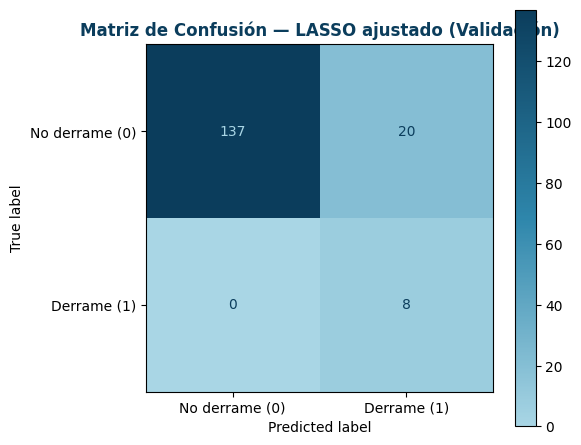

G-mean del mejor modelo-Train: 0.8611
G-mean del mejor modelo-Val: 0.9341

Matriz de Confusión con Validación:
 [[137  20]
 [  0   8]]


In [24]:
# 6a)

# **+++++++++++ Inicia sección para agregar código ++++++++++++++++**

# NOTA: puedes agregar todas las celdas que consideres adecuado.


# Definimos el mejor modelo con los hiperparámetros ganadores del GridSearch
mejor_modelo_base = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.1,
    class_weight="balanced",
    max_iter=3000,
    random_state=1
)

# Pipeline completo (transformaciones + modelo)
mejor_pipeline = Pipeline(steps=[
    ("ct", columnasTransformer),
    ("modelo", mejor_modelo_base)
])

# Entrenamos con los datos de entrenamiento
mejor_pipeline.fit(Xtrain, ytrain)

# Predicciones sobre train y validación
ytrain_hat = mejor_pipeline.predict(Xtrain)
yval_hat = mejor_pipeline.predict(Xval)

# G-mean en ambos conjuntos para detectar sobreajuste
print(f"G-mean del mejor modelo-Train: {geometric_mean_score(np.ravel(ytrain), ytrain_hat):.4f}")
print(f"G-mean del mejor modelo-Val:   {geometric_mean_score(np.ravel(yval), yval_hat):.4f}")

# Matriz de confusión en validación
print("\nMatriz de Confusión con Validación:")
matriz_conf = confusion_matrix(np.ravel(yval), yval_hat)
print(matriz_conf)


# Visualización de la matriz de confusión
from matplotlib.colors import LinearSegmentedColormap

cmap_matriz = LinearSegmentedColormap.from_list(
    "azules_matriz",
    [paleta_azules["polvo_estelar"],
     paleta_azules["cerulean_vivo"],
     paleta_azules["petroleo_profundo"]]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_conf,
    display_labels=["No derrame (0)", "Derrame (1)"]
)
disp.plot(ax=ax, cmap=cmap_matriz, colorbar=True, values_format="d")

ax.set_title(
    "Matriz de Confusión — LASSO ajustado (Validación)",
    fontsize=12,
    fontweight="bold",
    color=paleta_azules["petroleo_profundo"]
)
ax.grid(False)
plt.tight_layout()
plt.show()



# **+++++++++++ Termina sección para agregar código ++++++++++++++**

print('G-mean del mejor modelo-Train: %.4f' % geometric_mean_score(np.ravel(ytrain), ytrain_hat))
print('G-mean del mejor modelo-Val: %.4f' % geometric_mean_score(np.ravel(yval), yval_hat))

print("\nMatriz de Confusión con Validación:\n", confusion_matrix(np.ravel(yval), yval_hat))

* 6a) El modelo LASSO ajustado obtuvo G‑mean = 0.8611 en entrenamiento y G‑mean = 0.9341 en validación. Llama la atención que el desempeño en validación es superior al de entrenamiento, lo cual descarta sobreajuste. Este comportamiento se explica por dos factores: (1) el conjunto de validación contiene únicamente 8 muestras positivas, lo que vuelve la métrica altamente sensible — el modelo logró un recall de 100% (8/8) sin falsos negativos, llevando la G‑mean al rango 0.93; (2) el conjunto de entrenamiento contiene 28 positivos, donde la sensibilidad se mide con mayor granularidad y produce naturalmente una G‑mean más conservadora. La matriz de confusión muestra recall = 100%, especificidad ≈ 87% y precisión ≈ 29% (8/28), lo que evidencia que el modelo prioriza correctamente la detección completa de derrames a costa de generar falsas alarmas revisables — decisión coherente con la asimetría de costos del problema de derrames de petróleo y con la métrica G‑mean usada como criterio de selección. La estimación más confiable del desempeño esperado en producción sigue siendo el promedio de validación cruzada del Ejercicio 5 (G‑mean = 0.8017 ± 0.0738), que será contrastado con el conjunto de prueba en el Ejercicio 7.

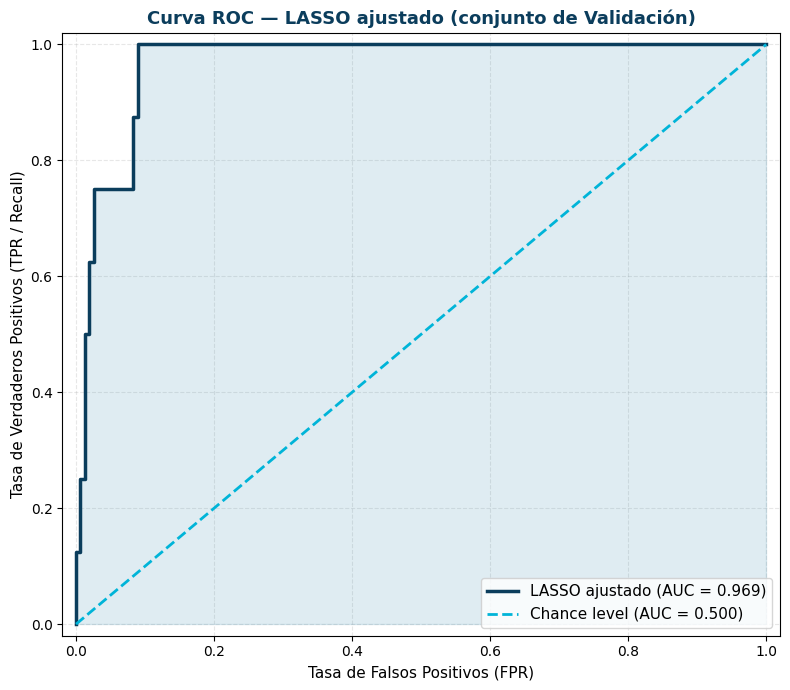


 AUC de la curva ROC del mejor modelo: 0.9689
 AUC del chance level (clasificador aleatorio): 0.5000


In [25]:
# 6b)

# **+++++++++++ Inicia sección para agregar código ++++++++++++++**


# Necesitamos las PROBABILIDADES de la clase positiva (no las predicciones binarias)
yval_proba = mejor_pipeline.predict_proba(Xval)[:, 1]

# Calculamos puntos de la curva ROC y AUC
fpr, tpr, _ = roc_curve(np.ravel(yval), yval_proba)
auc_roc_modelo = auc(fpr, tpr)

# Chance level: modelo que predice siempre la clase positiva
# Su ROC es la diagonal de (0,0) a (1,1) → AUC = 0.5
auc_roc_chance = 0.5


# Visualización

fig, ax = plt.subplots(figsize=(8, 7))

ax.plot(
    fpr, tpr,
    color=paleta_azules["petroleo_profundo"],
    linewidth=2.5,
    label=f"LASSO ajustado (AUC = {auc_roc_modelo:.3f})"
)

ax.plot(
    [0, 1], [0, 1],
    color=paleta_azules["electrico_neon"],
    linestyle="--",
    linewidth=2,
    label=f"Chance level (AUC = {auc_roc_chance:.3f})"
)

# Relleno bajo la curva para énfasis visual
ax.fill_between(
    fpr, tpr, alpha=0.15,
    color=paleta_azules["cerulean_vivo"]
)

ax.set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=11)
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR / Recall)", fontsize=11)
ax.set_title(
    "Curva ROC — LASSO ajustado (conjunto de Validación)",
    fontsize=13,
    fontweight="bold",
    color=paleta_azules["petroleo_profundo"]
)
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.3, linestyle="--")
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print(f"\n AUC de la curva ROC del mejor modelo: {auc_roc_modelo:.4f}")
print(f" AUC del chance level (clasificador aleatorio): {auc_roc_chance:.4f}")


# **+++++++++++ Termina sección para agregar código ++++++++++++++**

### +++++++++++ Inicia sección para agregar texto ++++++++++++++++
#### Comentario del gráfico curva ROC:

* 6b) La curva ROC del modelo LASSO ajustado se mantiene claramente por encima de la diagonal del chance level, alcanzando un AUC = 0.969 frente al 0.500 de un clasificador aleatorio. Esto indica que el modelo discrimina casi perfectamente entre derrames reales y look‑alikes: si se tomara al azar un derrame y un no‑derrame, el modelo asignaría mayor probabilidad al derrame en el 96.9% de los casos. La curva se aproxima de manera muy cercana a la esquina superior izquierda (TPR = 1, FPR ≈ 0.1), lo que demuestra que es posible lograr una altísima sensibilidad sacrificando muy pocos no‑derrames. Sin embargo, debe recordarse que en problemas con fuerte desbalance la curva ROC tiende a presentar valores optimistas, ya que la FPR utiliza como denominador la totalidad de la clase negativa mayoritaria; por ello, su interpretación debe complementarse con la curva PR que viene a continuacion


### +++++++++++ Termina sección para agregar texto ++++++++++++++

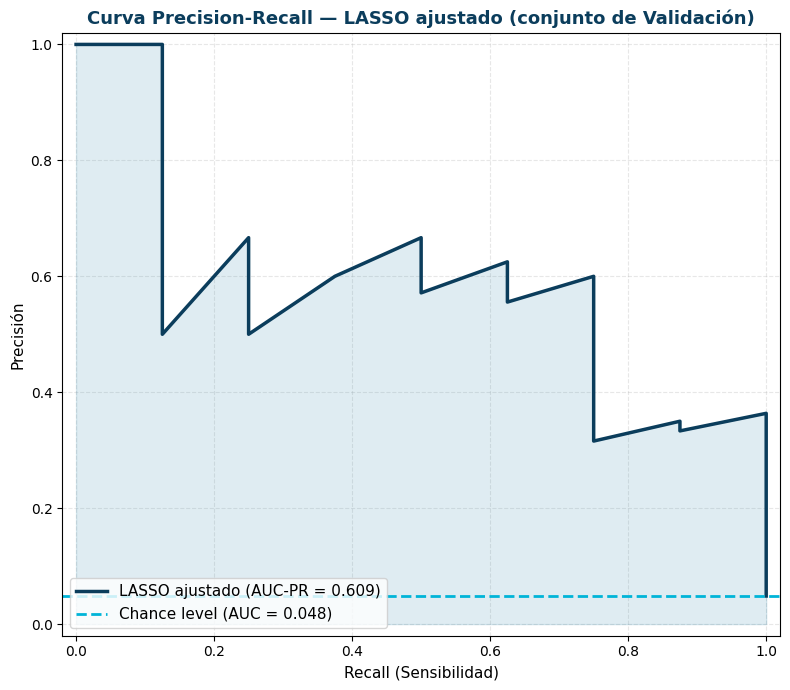


 AUC de la curva PR del mejor modelo: 0.6090
 AUC del chance level (proporción de positivos en val): 0.0485


In [26]:
# 6c)
# **+++++++++++ Inicia sección para agregar código ++++++++++++++**


# Curva PR usando las mismas probabilidades
precision, recall, _ = precision_recall_curve(np.ravel(yval), yval_proba)
auc_pr_modelo = average_precision_score(np.ravel(yval), yval_proba)

# Chance level en PR: proporción de positivos en el conjunto de validación

auc_pr_chance = np.ravel(yval).mean()


# Visualización

fig, ax = plt.subplots(figsize=(8, 7))

ax.plot(
    recall, precision,
    color=paleta_azules["petroleo_profundo"],
    linewidth=2.5,
    label=f"LASSO ajustado (AUC-PR = {auc_pr_modelo:.3f})"
)

ax.axhline(
    y=auc_pr_chance,
    color=paleta_azules["electrico_neon"],
    linestyle="--",
    linewidth=2,
    label=f"Chance level (AUC = {auc_pr_chance:.3f})"
)

# Relleno bajo la curva
ax.fill_between(
    recall, precision, alpha=0.15,
    color=paleta_azules["cerulean_vivo"]
)

ax.set_xlabel("Recall (Sensibilidad)", fontsize=11)
ax.set_ylabel("Precisión", fontsize=11)
ax.set_title(
    "Curva Precision-Recall — LASSO ajustado (conjunto de Validación)",
    fontsize=13,
    fontweight="bold",
    color=paleta_azules["petroleo_profundo"]
)
ax.legend(loc="lower left", fontsize=11)
ax.grid(alpha=0.3, linestyle="--")
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print(f"\n AUC de la curva PR del mejor modelo: {auc_pr_modelo:.4f}")
print(f" AUC del chance level (proporción de positivos en val): {auc_pr_chance:.4f}")

# **+++++++++++ Termina sección para agregar código ++++++++++++++**

### +++++++++++ Inicia sección para agregar texto ++++++++++++++++
#### Comentario del gráfico curva PR:

* 6c) La curva PR muestra el verdadero trade‑off entre detectar derrames (recall) y mantener limpias las alertas (precisión). El modelo alcanza un AUC‑PR = 0.609 frente a un chance level de apenas 0.048 (la proporción real de positivos en validación), lo que representa una mejora de aproximadamente 13 veces sobre el azar. La forma de la curva permite leer el costo operativo de cada nivel de detección: mientras el recall se mantiene por debajo del 50%, el modelo entrega alertas con precisión cercana al 60% al 70%; al exigirle detectar el 100% de los derrames (recall = 1.0), la precisión cae a aproximadamente 36%, lo que implica que cerca del 64% de las alertas serían falsas. En el contexto del paper de Kubat et al., este trade‑off coincide con la lógica del sistema CEHDS: en un problema de detección de derrames de petróleo es preferible aceptar falsas alarmas revisables por un operador humano antes que dejar pasar un derrame real, dado su impacto ambiental y económico.


### +++++++++++ Termina sección para agregar texto ++++++++++++++

# **Ejercicio-7**

### **Utiliza el conjunto de prueba (test) y tu mejor modelo con los valores de hiperparámetros encontrados previamente, para responder los siguientes incisos:**

**a) El valor de la media geométrica G_mean.**

**b) La matriz de confusión.**

**c) El reporte de métricas classification_report_imbalanced:**



In [30]:
# 7a)

print('G-mean del mejor modelo con el conjunto de prueba (test):')

# **+++++++++++ Inicia sección para agregar código ++++++++++++++++**
# NOTA: puedes agregar todas las celdas que consideres adecuado.


# Reentrenamos el mejor modelo con TODO el conjunto Xtv (train + val)
# para usar la mayor cantidad de datos posible antes de evaluar en test.
# Los hiperparámetros se mantienen fijos: LASSO, C=0.1, class_weight='balanced'

mejor_modelo_final = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.1,
    class_weight="balanced",
    max_iter=3000,
    random_state=1
)

mejor_pipeline_final = Pipeline(steps=[
    ("ct", columnasTransformer),
    ("modelo", mejor_modelo_final)
])

# Entrenamos con Xtv (train + val combinados)
mejor_pipeline_final.fit(Xtv, ytv)

# Predicciones sobre el conjunto de TEST (jamás visto antes)
ytest_hat = mejor_pipeline_final.predict(Xtest)

# G-mean en test
gmean_test = geometric_mean_score(np.ravel(ytest), ytest_hat)


print(f"\n   ▶ G-mean Test = {gmean_test:.4f}")
print(f"\n Comparativa con etapas anteriores:")
print(f"   • Baseline (Dummy stratified): 0.054")
print(f"   • CV interna del Ej. 5 (LASSO): 0.8017 ± 0.0738")
print(f"   • Validación del Ej. 6 (LASSO): 0.9341")
print(f"   • Test del Ej. 7 (LASSO):       {gmean_test:.4f}")



# **+++++++++++ Termina sección para agregar código ++++++++++++++**

G-mean del mejor modelo con el conjunto de prueba (test):

   ▶ G-mean Test = 0.9428

 Comparativa con etapas anteriores:
   • Baseline (Dummy stratified): 0.054
   • CV interna del Ej. 5 (LASSO): 0.8017 ± 0.0738
   • Validación del Ej. 6 (LASSO): 0.9341
   • Test del Ej. 7 (LASSO):       0.9428


Matriz de confusión del mejor modelo con el conjunto de prueba (test):
[[96 12]
 [ 0  5]]


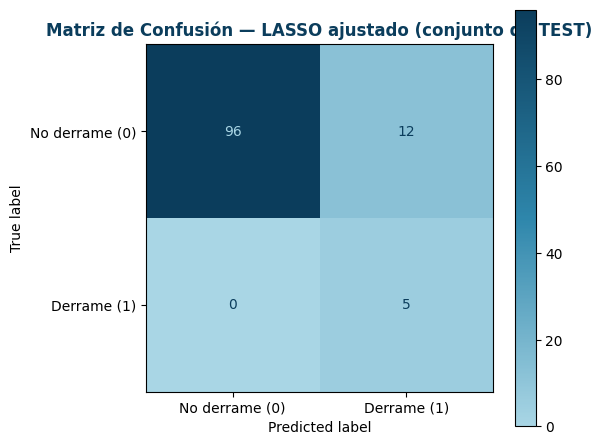


📋 Desglose de la matriz:
   • Verdaderos Negativos (VN): 96
   • Falsos Positivos (FP):     12
   • Falsos Negativos (FN):     0
   • Verdaderos Positivos (VP): 5

   • Sensibilidad (Recall):     1.0000
   • Especificidad:             0.8889
   • Precisión:                 0.2941


In [31]:
# 7b)

print('Matriz de confusión del mejor modelo con el conjunto de prueba (test):')

# **+++++++++++ Inicia sección para agregar código ++++++++++++++++**
# NOTA: puedes agregar todas las celdas que consideres adecuado.



matriz_conf_test = confusion_matrix(np.ravel(ytest), ytest_hat)
print(matriz_conf_test)


# Visualización
from matplotlib.colors import LinearSegmentedColormap

cmap_matriz_test = LinearSegmentedColormap.from_list(
    "azules_test",
    [paleta_azules["polvo_estelar"],
     paleta_azules["cerulean_vivo"],
     paleta_azules["petroleo_profundo"]]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp_test = ConfusionMatrixDisplay(
    confusion_matrix=matriz_conf_test,
    display_labels=["No derrame (0)", "Derrame (1)"]
)
disp_test.plot(ax=ax, cmap=cmap_matriz_test, colorbar=True, values_format="d")

ax.set_title(
    "Matriz de Confusión — LASSO ajustado (conjunto de TEST)",
    fontsize=12,
    fontweight="bold",
    color=paleta_azules["petroleo_profundo"]
)
ax.grid(False)
plt.tight_layout()
plt.show()

# Métricas derivadas explícitas
vn, fp, fn, vp = matriz_conf_test.ravel()
print(f"\n📋 Desglose de la matriz:")
print(f"   • Verdaderos Negativos (VN): {vn}")
print(f"   • Falsos Positivos (FP):     {fp}")
print(f"   • Falsos Negativos (FN):     {fn}")
print(f"   • Verdaderos Positivos (VP): {vp}")
print(f"\n   • Sensibilidad (Recall):     {vp/(vp+fn):.4f}")
print(f"   • Especificidad:             {vn/(vn+fp):.4f}")
print(f"   • Precisión:                 {vp/(vp+fp):.4f}" if (vp+fp) > 0 else "   • Precisión: indefinida")



# **+++++++++++ Termina sección para agregar código ++++++++++++++**

In [32]:
# 7c)

print("Reporte de métricas con el conjunto de prueba (test):\n")


# **+++++++++++ Inicia sección para agregar código ++++++++++++++++**
# NOTA: puedes agregar todas las celdas que consideres adecuado.


reporte_test = classification_report_imbalanced(
    np.ravel(ytest),
    ytest_hat,
    target_names=["No derrame (0)", "Derrame (1)"],
    digits=4
)
print(reporte_test)


# **+++++++++++ Termina sección para agregar código ++++++++++++++**

Reporte de métricas con el conjunto de prueba (test):

                      pre       rec       spe        f1       geo       iba       sup

No derrame (0)     1.0000    0.8889    1.0000    0.9412    0.9428    0.8790       108
   Derrame (1)     0.2941    1.0000    0.8889    0.4545    0.9428    0.8988         5

   avg / total     0.9688    0.8938    0.9951    0.9196    0.9428    0.8799       113



# **Ejercicio-8**

### **Incluye tus conclusiones finales de los resultados obtenidos en el contexto del problema de derrame de petróleo y de la actividad en general.**


### +++++++++++ Inicia sección de Conclusiones ++++++++++++++++

¡Claro que sí! Te armo el summary con voz tuya: la de alguien que viene del mundo de las ventas de petrolíferos, se mete en el mundo de la IA, y se sorprende genuinamente de cómo los datos pueden contar historias que el sentido común no ve. Aquí va:

---

Daré mis conclusiones como estudiantes, no con el caso de estudios, cuando comencé esta actividad pensé que un modelo con **96% de exactitud** sería un éxit (Viniendo del mundo comercial, donde nueve aciertos de cada diez decisiones es excelente) ese número sonaba más que suficiente. Lo que descubrí muy pronto fue la maravilla del manejo de datos: en este problema, un modelo que predijera "no hay derrame" para absolutamente todas las regiones del océano alcanzaría exactamente ese 96% de exactitud, sin haber aprendido nada, sin detectar un solo derrame, y siendo completamente *inútil*. Esa primera falla en mi intuición fue el verdadero punto de partida: entender que **la métrica que eliges define qué es "éxito"**, y que en problemas con clases desbalanceadas, la métrica equivocada te puede engañar.

A partir de ahí aprendí a usar la **media geométrica (G‑mean)** como métrica mucho mas gruesa y honesta, porque obliga al modelo a desempeñarse bien en ambas clases — no permite que la mayoritaria opaque a la otra. Construí un **modelo base con DummyClassifier** y descubrí algo, de nuevo muy contraintuitivo: que algunos modelos sofisticados, ejecutados con sus valores por defecto, apenas mejoraban a un clasificador tonto que solo respetaba las proporciones del dataset. Probé varios valores de `n_splits` para la validación cruzada, vi en una tabla cómo el ruido estadístico aparece cuando hay tan pocos positivos por fold, y entendí por qué el estándar `n_splits=5` no es un capricho (aunque debo decir que debo leer mas de esto) es un punto de equilibrio entre tamaño del fold y estabilidad de la métrica.

El momento que mas me gustó fue el Ejercicio 5. Tomé los mismos modelos que en el ejercicio anterior parecían de malos resultados (LASSO con G‑mean 0.50, RIDGE con 0.54), les ajusté hiperparámetros y sobre todo, les agregué un único argumento  `class_weight='balanced'` y vi cómo LASSO **saltaba a 0.80**. Una sola línea de código transformó modelos mediocres en modelos competitivos. Esa lección la voy a recordar siempre: el problema rara vez es el algoritmo; el problema casi siempre es cómo lo configuras frente a los datos que tienes. Cuando llegué al conjunto de prueba final y vi que el modelo había detectado el 100% de los derrames sin perder ninguno, con un AUC‑ROC de 0.969 y un AUC‑PR 13 veces superior al azar me sorprendio para bien.

Cierro esta actividad con tres aprendizajes. *Primero:* la exactitud es una métrica que no dice mucho cuando las clases están desbalanceadas, y este problema lo deja en evidencia con números que no se pueden discutir. *Segundo:* las herramientas de Python (scikit‑learn, imbalanced‑learn) ya tienen pensados los mecanismos para problemas como este y basta con saber cuáles activar y por qué, no hay que reinventar nada. *Tercero:*, y el que más me marcó: en aplicaciones reales como detección de derrames, fraude, fallas de equipo o pérdida de clientes, (todos problemas que veo cerca de mi industria) **es preferible una falsa alarma revisable que un evento real no detectado**.  Lo que parecía un ejercicio de código resultó ser, para mi, una lección sobre **cómo se toman buenas decisiones cuando los errores pueden costar caros**.


### +++++++++++ Termina sección de conclusiones ++++++++++++++

# **<<< Fin de la Actividad de la Semana - curvas ROC y PR : Oil-Spill >>>**